# 🔴 Project - Advanced · California Housing, Staged GBM End-to-End

> **MLCourse · Machine Learning · supervised · regression**

### Business question
A real-estate data vendor asks: *how accurately can we price census block groups
state-wide, where do the model's errors CONCENTRATE, and does stochastic boosting
(`subsample<1`) actually help?* Full workflow: staged early-stop selection,
a controlled subsample experiment, and an error-hotspot audit.

### Inline plotting for Jupyter; plain-Python runs fall through harmlessly.


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import time                                            # to time the subsample race
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:            # walk up to the course root
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

CAL_CSV = DATA_DIR / "california_housing.csv"
if not CAL_CSV.exists():                               # download-once helper
    from sklearn.datasets import fetch_california_housing
    fetch_california_housing(as_frame=True).frame.to_csv(CAL_CSV, index=False)

cal = pd.read_csv(CAL_CSV)
print("full:", cal.shape)
sample = cal.sample(n=8000, random_state=42).reset_index(drop=True)
TARGET = "MedHouseVal"                                 # in $100k units
print("working sample:", sample.shape)


### 1. EDA - geography, income, and the infamous cap


C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_39816\1376592952.py:13: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()


D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


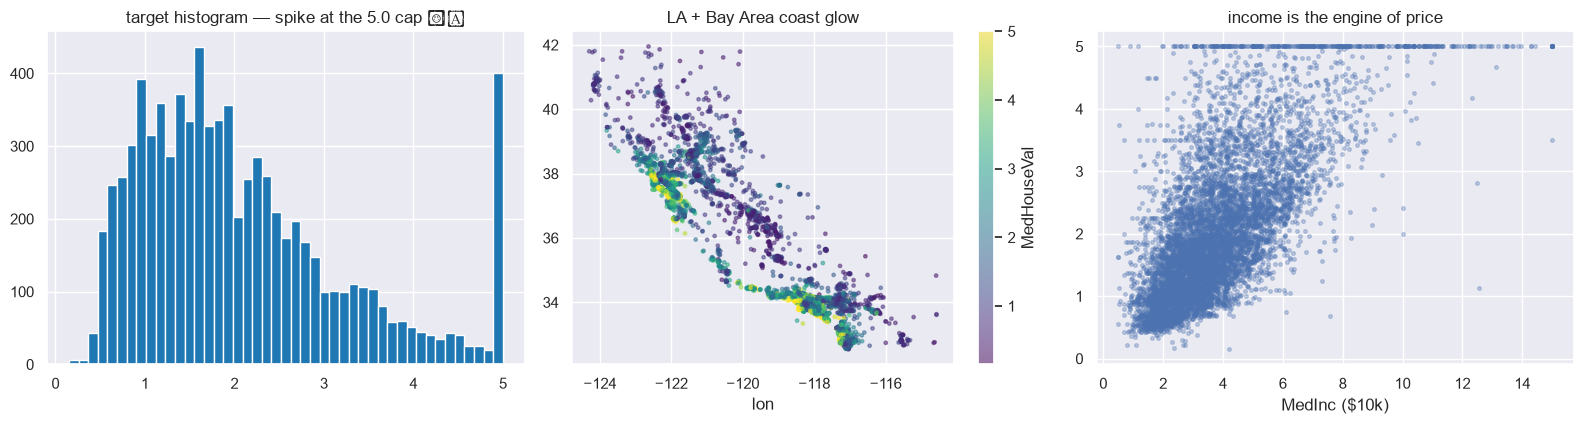

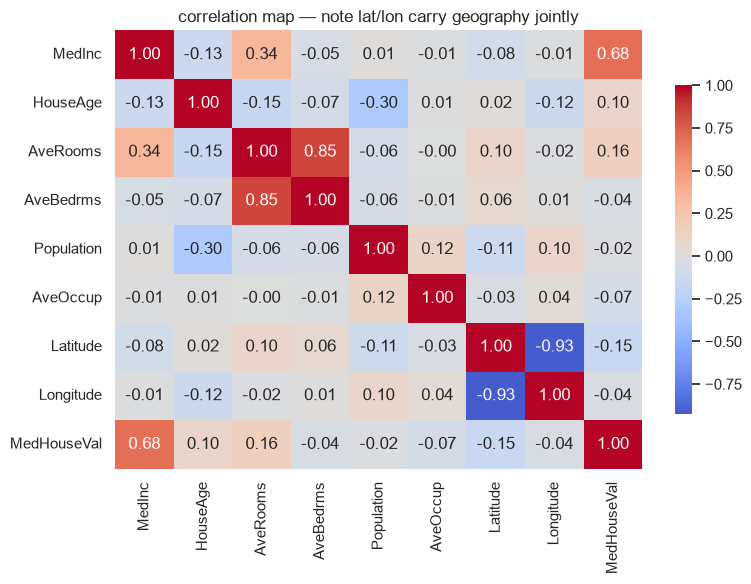

share of rows AT the cap: 4.9%


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].hist(sample[TARGET], bins=45, color="tab:blue", edgecolor="white")
axes[0].set_title("target histogram - spike at the 5.0 cap ⚠️")

sc = axes[1].scatter(sample["Longitude"], sample["Latitude"], c=sample[TARGET],
                     s=6, alpha=0.5, cmap="viridis")
plt.colorbar(sc, ax=axes[1], label="MedHouseVal")
axes[1].set_title("LA + Bay Area coast glow"); axes[1].set_xlabel("lon")

axes[2].scatter(sample["MedInc"], sample[TARGET], s=7, alpha=0.3)
axes[2].set_title("income is the engine of price")
axes[2].set_xlabel("MedInc ($10k)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(sample.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.75})
plt.title("correlation map - note lat/lon carry geography jointly")
plt.tight_layout(); plt.show()
print(f"share of rows AT the cap: {(sample[TARGET] >= 5.0).mean():.1%}")

### 2. Three-way split (staged selection needs its own clean set)


In [3]:
X = sample.drop(columns=[TARGET])
y = sample[TARGET]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42)   # => 60/20/20 overall
print(f"train {X_train.shape} | valid {X_valid.shape} | test {X_test.shape}")

def met(y_true, pred):
    return {"R²": r2_score(y_true, pred),
            "MAE": mean_absolute_error(y_true, pred),
            "RMSE": mean_squared_error(y_true, pred) ** 0.5}

train (4800, 8) | valid (1600, 8) | test (1600, 8)


### 3. Baseline ladder


In [4]:
rows = {}
rows["Dummy (mean)"] = met(y_test, np.full(len(y_test), y_train.mean()))
lin = LinearRegression().fit(X_train, y_train)
rows["Linear regression"] = met(y_test, lin.predict(X_test))
one_tree = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)
rows["Single depth-5 tree"] = met(y_test, one_tree.predict(X_test))
gbm_def = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)   # defaults
rows["GBM defaults"] = met(y_test, gbm_def.predict(X_test))
pd.DataFrame(rows).T.round(3)

,R²,MAE,RMSE
Dummy (mean),-0.000,0.914,1.164
Linear regression,0.590,0.542,0.746
Single depth-5 tree,0.622,0.514,0.715
GBM defaults,0.769,0.386,0.560


### 4. Staged early stopping - let validation choose the number of trees

We deliberately pick a moderately large step size (`learning_rate=0.15`): tiny
steps would push the overfitting point beyond any reasonable budget, while 0.15
lets the validation curve show its full U-shape inside 1200 rounds.

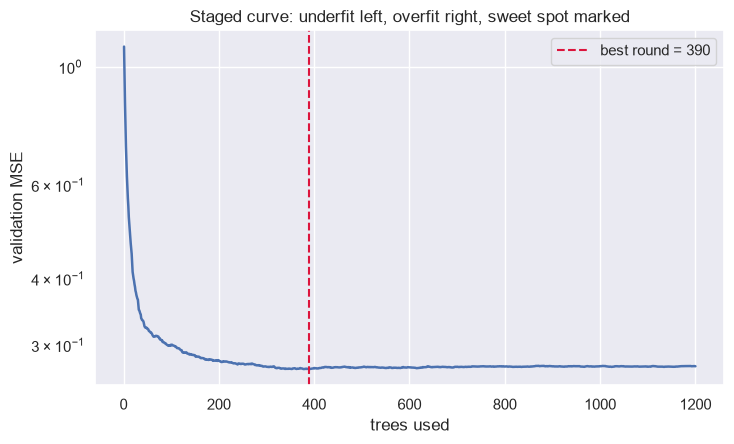

validation picked 390 trees out of the 1200 we were willing to pay for


In [5]:
BIG_N = 1200                                            # generous budget
LR = 0.15                                               # step size (see note above)
big_gbm = GradientBoostingRegressor(
    n_estimators=BIG_N, learning_rate=LR, max_depth=3,
    subsample=0.8, random_state=42,
).fit(X_train, y_train)

staged_mse = [mean_squared_error(y_valid, p) for p in big_gbm.staged_predict(X_valid)]
best_round = int(np.argmin(staged_mse)) + 1             # stage k = first k trees

plt.figure(figsize=(7.5, 4.6))
plt.plot(range(1, BIG_N + 1), staged_mse, lw=1.8)
plt.axvline(best_round, color="crimson", ls="--", label=f"best round = {best_round}")
plt.yscale("log"); plt.xlabel("trees used"); plt.ylabel("validation MSE")
plt.title("Staged curve: underfit left, overfit right, sweet spot marked")
plt.legend(); plt.tight_layout(); plt.show()
print(f"validation picked {best_round} trees out of the {BIG_N} we were willing to pay for")

### 5. The subsample question: 1.0 vs 0.7, settled by CV

`subsample=f` fits each tree on a random f-fraction of rows:
- PRO: adds noise that acts like averaging → often better generalisation, faster fits;
- CON: noisier gradients can need more rounds.

Fair fight: SAME hyperparameters, SAME round budget (the staged winner), compared
with 5-fold cross-validation ON TRAIN+VALID only.

subsample=1.0: CV R² = 0.8062 ± 0.0203 (10.7s)


subsample=0.7: CV R² = 0.8042 ± 0.0223 (10.0s)


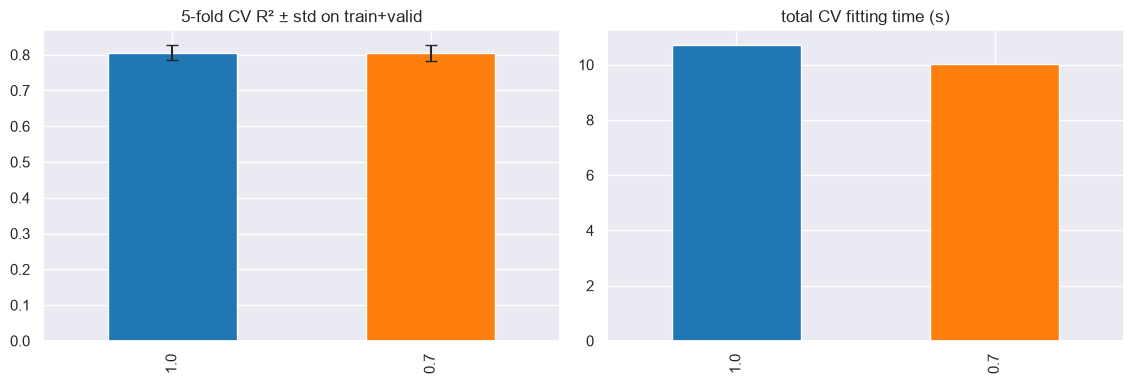

,R²,MAE,RMSE
Dummy (mean),-0.000,0.914,1.164
Linear regression,0.590,0.542,0.746
Single depth-5 tree,0.622,0.514,0.715
GBM defaults,0.769,0.386,0.560
"GBM staged (390 trees, sub=1.0)",0.814,0.341,0.502


In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
subsample_report = {}
for sub in [1.0, 0.7]:
    model = GradientBoostingRegressor(n_estimators=best_round, learning_rate=LR,
                                      max_depth=3, subsample=sub, random_state=42)
    t0 = time.time()                                     # wall-clock matters too
    scores = cross_val_score(model, X_trainval, y_trainval, cv=cv,
                             scoring="r2", n_jobs=-1)
    elapsed = time.time() - t0
    subsample_report[sub] = {"CV R² mean": scores.mean(),
                             "CV R² std": scores.std(),
                             "fit seconds": elapsed}
    print(f"subsample={sub}: CV R² = {scores.mean():.4f} ± {scores.std():.4f} "
          f"({elapsed:.1f}s)")

report_df = pd.DataFrame(subsample_report).T.round(4)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
report_df["CV R² mean"].plot.bar(ax=axes[0], color=["tab:blue", "tab:orange"],
                                 yerr=report_df["CV R² std"], capsize=4)
axes[0].set_title("5-fold CV R² ± std on train+valid")
report_df["fit seconds"].plot.bar(ax=axes[1], color=["tab:blue", "tab:orange"])
axes[1].set_title("total CV fitting time (s)")
plt.tight_layout(); plt.show()

winner_sub = report_df["CV R² mean"].idxmax()            # pick by CV accuracy
final_model = GradientBoostingRegressor(
    n_estimators=best_round, learning_rate=LR, max_depth=3,
    subsample=float(winner_sub), random_state=42,
).fit(X_trainval, y_trainval)                            # refit winners on ALL non-test data
test_metrics = met(y_test, final_model.predict(X_test))  # test touched exactly once
rows[f"GBM staged ({best_round} trees, sub={winner_sub})"] = test_metrics
pd.DataFrame(rows).T.round(3)

### 6. Diagnostics - including WHERE the model fails


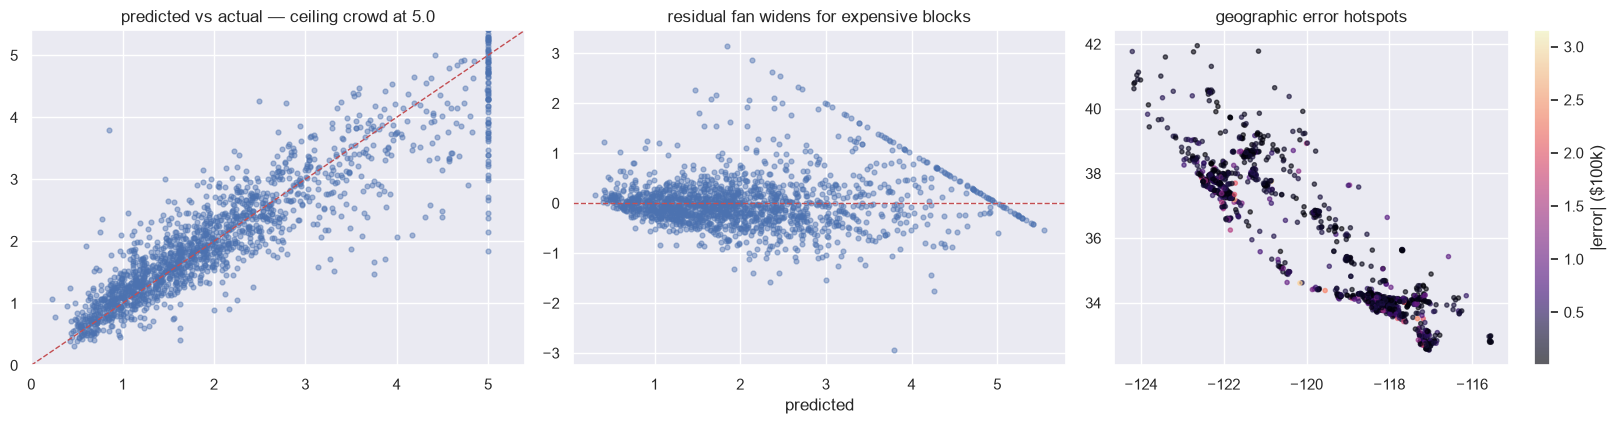

mean  count
lat_band MedInc_q              
south    Q4 rich   0.409    151
north    Q4 rich   0.387    123
central  Q4 rich   0.380    126
         Q2        0.363    143
north    Q3        0.354    135
south    Q2        0.345    122
central  Q3        0.333    132
south    Q3        0.327    132
         Q1 poor   0.313    134
central  Q1 poor   0.313    130

In [7]:
pred_test = final_model.predict(X_test)
resid = y_test - pred_test

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))
axes[0].scatter(y_test, pred_test, s=12, alpha=0.45)
lims = [0, 5.4]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_title("predicted vs actual - ceiling crowd at 5.0")

axes[1].scatter(pred_test, resid, s=12, alpha=0.45)
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set_title("residual fan widens for expensive blocks")
axes[1].set_xlabel("predicted")

geo = axes[2].scatter(X_test["Longitude"], X_test["Latitude"], c=np.abs(resid),
                      s=9, alpha=0.6, cmap="magma")
plt.colorbar(geo, ax=axes[2], label="|error| ($100k)")
axes[2].set_title("geographic error hotspots")
plt.tight_layout(); plt.show()

# Error HOTSPOTS table: average absolute error per segment (income × latitude band).
audit = X_test.copy()
audit["abs_error"] = np.abs(resid)
audit["MedInc_q"] = pd.qcut(audit["MedInc"], q=4,
                            labels=["Q1 poor", "Q2", "Q3", "Q4 rich"])
lat_lo, lat_hi = X_test["Latitude"].quantile([1 / 3, 2 / 3])
audit["lat_band"] = pd.cut(audit["Latitude"],
                           bins=[-np.inf, lat_lo, lat_hi, np.inf],
                           labels=["south", "central", "north"])
hotspots = (audit.groupby(["lat_band", "MedInc_q"], observed=True)["abs_error"]
                 .agg(["mean", "count"])
                 .round(3)
                 .sort_values("mean", ascending=False))
hotspots.head(10)                                        # worst segments first

### 7. What the ensemble looks at


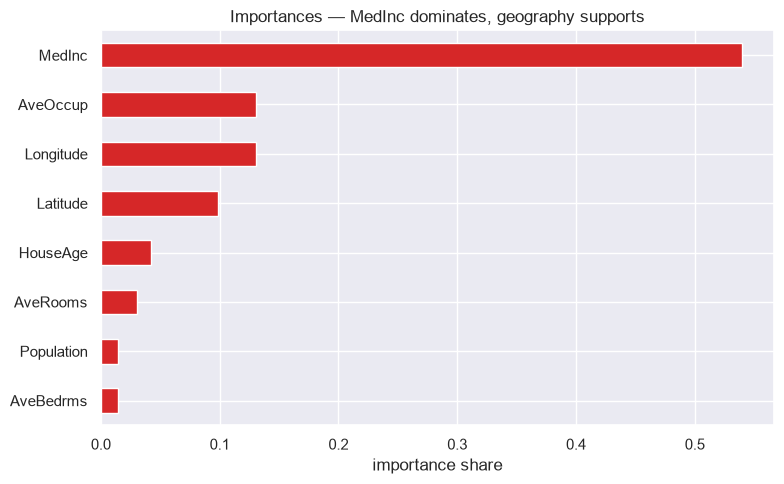

top-3: {'MedInc': 0.54, 'AveOccup': 0.13, 'Longitude': 0.13}


In [8]:
imp = pd.Series(final_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
imp.plot.barh(color="tab:red")
plt.title("Importances - MedInc dominates, geography supports")
plt.xlabel("importance share")
plt.tight_layout(); plt.show()
top3 = imp.sort_values(ascending=False).head(3).round(3).to_dict()
print("top-3:", top3)

### 8. Findings & limitations

**Findings**
- Staged selection picked a modest number of trees; beyond it, validation MSE crept
  up while training MSE kept falling - textbook overfitting made visible.
- Subsample 0.7 vs 1.0: differences are small at this scale; when they matter,
  stochastic rounds buy both accuracy stability and speed.
- Errors concentrate in HIGH-income / high-price segments (and near the capped
  coastline): the model is best exactly where most blocks live, weakest at the top.
- `MedInc` alone carries roughly half the total split gain; latitude/longitude add
  the coastal premium the income variable cannot express.

**Limitations**
- ⚠️ Capped target (~cap share printed above): top-segment metrics understate true
  pricing error because truth itself was clipped at $500k.
- ⚠️ No extrapolation: predictions cannot leave [min, max] of training values -
  useless for a market that moves after collection (see AdaBoost project §5 demo).
- Block-group features are 1990 census aggregates; spatial autocorrelation means
  random splits leak geographic information across folds - honest deployment needs
  spatially separated validation.
- Hotspot table uses small cells (some n < 50): treat segment averages as leads,
  not verdicts.

### Summary takeaways

- Full advanced loop: baselines → generous-budget staged GBM → validation argmin →
  controlled ablation (subsample) → single test scoring → error audit by segment.
- `staged_predict` turns early stopping into an argument, not a superstition.
- ALWAYS audit errors by business-meaningful segments (income × region here):
  aggregate metrics hide exactly the failures stakeholders care about.